# Лабораторная работа №4

## Баканов Сергей ИБМ3-65Б

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import *
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('ai.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [4]:
data = data[:10000]

In [5]:
data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


In [6]:
X = data.drop("Burnout_Risk_Level", axis = 1)
y = data['Burnout_Risk_Level']

In [7]:
from sklearn.preprocessing import LabelEncoder

X_encoded = X.copy()

categorical_columns = X_encoded.select_dtypes(include=['str', 'bool']).columns

for col in categorical_columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_encoded.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
0,100001,2,3,2.418,23.31,0,1,1,1,8.13,5,1,6,2.393,86.44
1,100002,3,2,3.821,1.12,3,0,5,0,16.65,3,1,9,3.696,69.39
2,100003,1,0,3.398,21.26,4,1,2,0,10.35,5,2,9,3.499,73.93
3,100004,1,3,3.789,1.82,0,2,4,0,15.23,2,1,2,4.000,63.58
4,100005,4,4,3.635,9.29,1,0,4,0,12.55,4,1,4,3.798,100.00


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)

C:\Users\nobro\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [12]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_log = log_reg.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM', 'Дерево решений'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_tree, average='weighted')
    ]
})

results

,Модель,Accuracy,F1-score
0,Логистическая регрессия,0.5065,0.506220
1,SVM,0.4140,0.242427
2,Дерево решений,0.4930,0.493442


In [13]:
feature_importance = pd.DataFrame({'Признак': X_encoded.columns, 'Важность': tree_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Важность',ascending=False)

feature_importance.head(10)

,Признак,Важность
4,Weekly_GenAI_Hours,0.793444
2,Year_of_Study,0.054349
11,Institutional_Policy,0.039027
13,Post_Semester_GPA,0.032969
10,Perceived_AI_Dependency,0.031030
3,Pre_Semester_GPA,0.017480
9,Traditional_Study_Hours,0.007257
14,Skill_Retention_Score,0.006728
12,Anxiety_Level_During_Exams,0.006522
5,Primary_Use_Case,0.004898


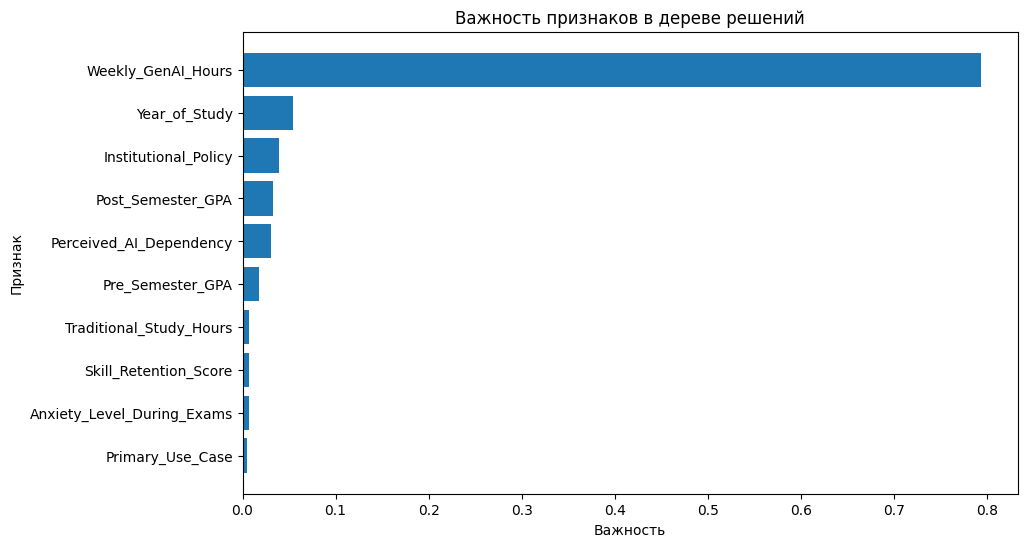

In [14]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Признак'][:10],
    feature_importance['Важность'][:10]
)

plt.xlabel('Важность')
plt.ylabel('Признак')
plt.title('Важность признаков в дереве решений')

plt.gca().invert_yaxis()

plt.show()

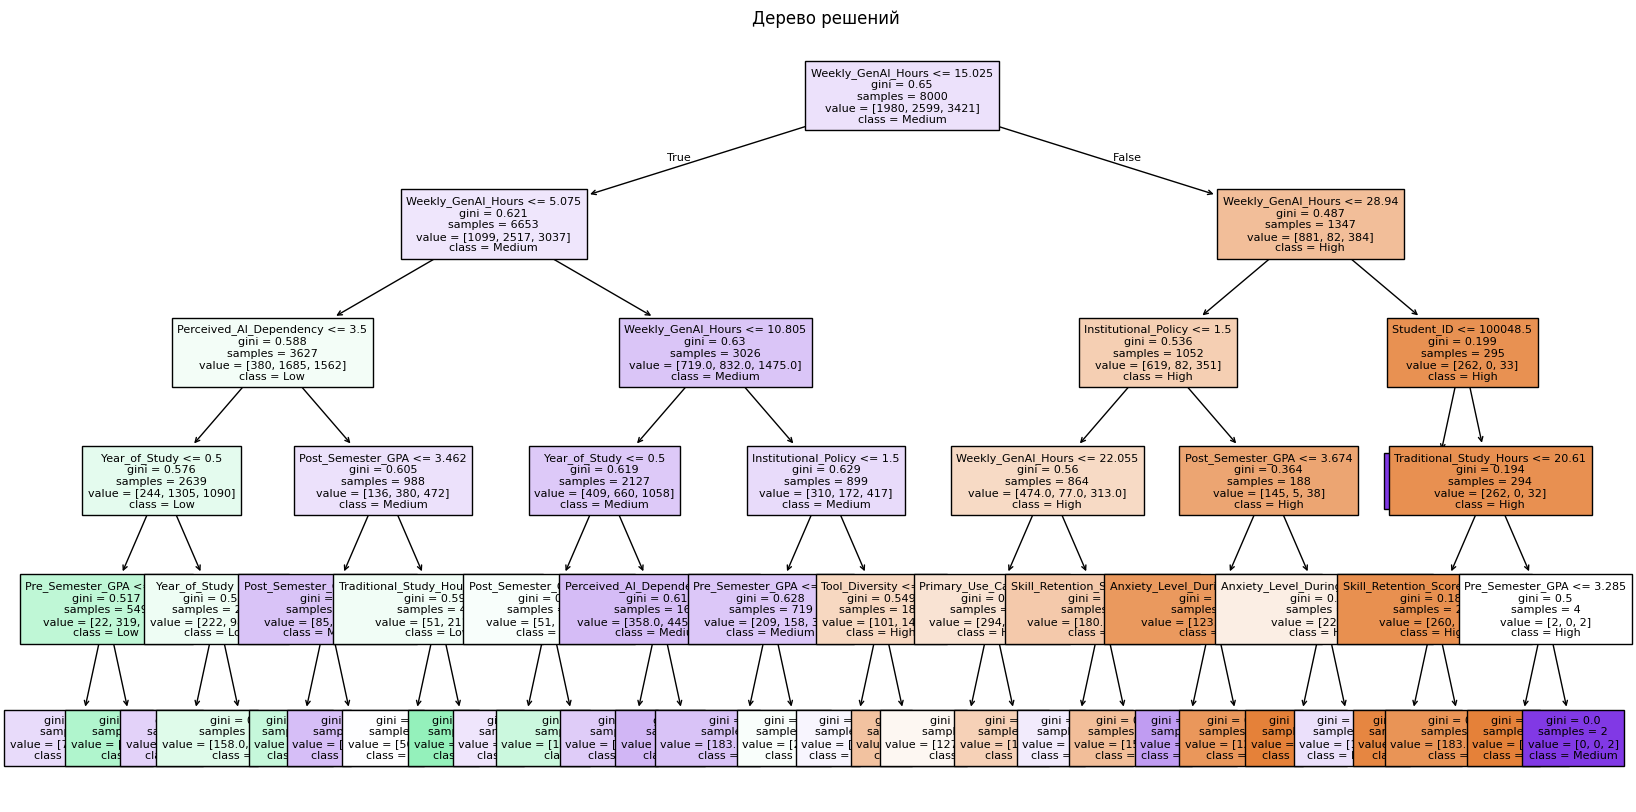

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X_encoded.columns,
    class_names=target_encoder.classes_,
    filled=True,
    fontsize=8
)

plt.title('Дерево решений')

plt.show()